# P13 - Qualite des donnees et EDA approfondie

Ce notebook couvre :
1. Disponibilite et volumetrie des tables
2. Valeurs manquantes
3. Statistiques descriptives (variables quantitatives)
4. Variables qualitatives - modalites et encodage
5. Distributions et outliers
6. Matrice de correlations features → cibles ML
7. Conclusions et recommandations


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if Path('/app/src').exists():
    sys.path.insert(0, '/app/src')
else:
    sys.path.insert(0, '../../src')

from p13.db import read_sql
from p13.ml.features import ALL_TARGETS, FEATURE_COLUMNS

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


## 1. Volumetrie des tables


In [2]:
tables = [
    'communes', 'stats_communes', 'ecoles_effectifs',
    'mutations_dvf', 'permis_construire', 'population_2014',
    'referentiel_batiment', 'ml_dataset_commune',
]

vol = []
for t in tables:
    try:
        n = read_sql(f'SELECT COUNT(*) AS n FROM {t}').iloc[0]['n']
        ncols = len(read_sql(f'SELECT * FROM {t} LIMIT 1').columns)
        vol.append({'table': t, 'lignes': int(n), 'colonnes': ncols})
    except Exception as e:
        vol.append({'table': t, 'lignes': -1, 'colonnes': 0})

df_vol = pd.DataFrame(vol)
df_vol


,table,lignes,colonnes
0,communes,43,9
1,stats_communes,43,33
2,ecoles_effectifs,3412,16
3,mutations_dvf,145387,14
4,permis_construire,10810,15
5,population_2014,688,6
6,referentiel_batiment,147088,11
7,ml_dataset_commune,688,17


## 2. Valeurs manquantes

Analyse du taux de nulls par colonne sur les tables principales.


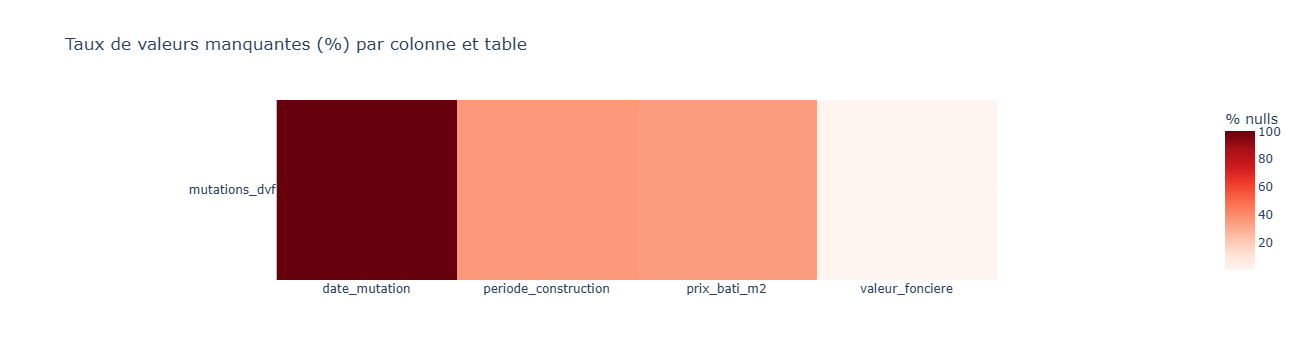

In [3]:
def missing_report(table, limit=500):
    df = read_sql(f'SELECT * FROM {table} LIMIT {limit}')
    miss = (df.isna().sum() / len(df) * 100).round(2)
    miss = miss[miss > 0].sort_values(ascending=False)
    return miss.rename(table)

reports = []
for t in ['ml_dataset_commune', 'stats_communes', 'mutations_dvf']:
    r = missing_report(t)
    if not r.empty:
        reports.append(r)

if reports:
    miss_df = pd.concat(reports, axis=1).fillna(0)
    fig = px.imshow(
        miss_df.T,
        title='Taux de valeurs manquantes (%) par colonne et table',
        color_continuous_scale='Reds',
        labels={'color': '% nulls'}
    )
    fig.show()
    miss_df
else:
    print('Aucune valeur manquante detectee dans les tables analysees.')


## 3. Statistiques descriptives — variables quantitatives

Statistiques classiques sur le dataset ML (features + cibles).


In [4]:
ml = read_sql('SELECT * FROM ml_dataset_commune')
print(f'Dataset ML : {ml.shape[0]} lignes x {ml.shape[1]} colonnes')
ml.head()


Dataset ML : 688 lignes x 17 colonnes


,id,code_insee,rentree,nb_eleves_maternelle,nb_eleves_elementaire,nb_classes,population,pop_0_14_pct,natalite,densite,log_collectif,log_individuel,plh_logements,nb_mutations,nb_logements_parcelle,nb_batiments,nb_permis_logements
0,1,35001,2018,271.00,462.00,29.00,6874,20.00,7.40,233.00,91,2035,456,1930,91058,147088,0
1,2,35245,2023,206.00,300.00,20.00,4189,23.00,10.80,144.00,67,1483,270,0,91058,147088,0
2,3,35210,2022,348.00,697.00,43.00,11703,20.20,8.30,341.00,152,3022,780,3253,91058,147088,0
3,4,35206,2017,231.00,411.00,25.00,8359,16.90,14.10,288.00,125,2055,780,2735,91058,147088,0
4,5,35079,2014,104.00,168.00,11.00,2397,22.40,7.20,229.00,27,786,162,0,91058,147088,0


In [5]:
desc = ml[FEATURE_COLUMNS + ALL_TARGETS].describe().T
desc['cv_%'] = (desc['std'] / desc['mean'].abs() * 100).round(1)
desc = desc.round(2)
desc


,count,mean,std,min,25%,50%,75%,max,cv_%
population,688.00,11166.93,34222.23,677.00,2397.00,4738.00,8667.00,230890.00,306.50
pop_0_14_pct,688.00,20.47,3.16,13.70,18.50,20.20,23.00,27.70,15.40
natalite,688.00,11.09,2.78,7.20,8.50,10.80,12.90,17.90,25.00
densite,688.00,509.93,666.45,59.00,223.00,323.00,569.00,4467.00,130.70
log_collectif,688.00,218.65,900.23,1.00,27.00,66.00,134.00,6032.00,411.70
log_individuel,688.00,1884.07,2318.06,244.00,784.00,1377.00,2055.00,15481.00,123.00
plh_logements,688.00,737.37,1540.54,36.00,168.00,360.00,720.00,10200.00,208.90
nb_mutations,688.00,3381.09,11581.91,0.00,363.00,1266.00,2628.00,77758.00,342.50
nb_permis_logements,688.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
nb_eleves_maternelle,688.00,382.99,1086.87,0.00,106.75,198.00,310.25,7659.00,283.80


**Lecture :**
- `cv_%` (coefficient de variation) indique la dispersion relative : > 100% = feature tres heterogene entre communes.
- Comparer `min` et `max` pour reperer des valeurs aberrantes potentielles.
- Comparer `mean` et `50%` (mediane) : un ecart important signale une distribution asymetrique.


## 4. Variables qualitatives — modalites

Recensement des valeurs distinctes dans les colonnes categoriques.


In [6]:
dvf = read_sql('SELECT type_bien, periode_construction FROM mutations_dvf LIMIT 5000')
ecoles = read_sql('SELECT secteur FROM ecoles_effectifs LIMIT 5000')
permis = read_sql('SELECT etat_projet, type_habitation FROM permis_construire LIMIT 5000')

print('=== DVF - type_bien ===')
print(dvf['type_bien'].value_counts(dropna=False).head(20))
print()
print('=== DVF - periode_construction ===')
print(dvf['periode_construction'].value_counts(dropna=False))
print()
print('=== Ecoles - secteur (public/prive) ===')
print(ecoles['secteur'].value_counts(dropna=False))
print()
print('=== Permis - etat_projet ===')
print(permis['etat_projet'].value_counts(dropna=False))


=== DVF - type_bien ===
type_bien
Appartement          1350
Maison               1311
Autres               1026
Terrain               850
Dépendance            257
Locaux d'activité     206
Name: count, dtype: int64

=== DVF - periode_construction ===
periode_construction
None         2202
1990-2012    1181
>= 2013       538
1975-1989     340
1961-1974     335
< 1914        268
1945-1960      96
1914-1944      40
Name: count, dtype: int64

=== Ecoles - secteur (public/prive) ===
secteur
SECTEUR PUBLIC    1627
PUBLIC             969
SECTEUR PRIVE      510
PRIVE              306
Name: count, dtype: int64

=== Permis - etat_projet ===
etat_projet
Chantier terminé     2916
Chantier commencé    1343
Autorisé              583
Annulé                158
Name: count, dtype: int64


**Conclusion :** `date_mutation` est inutilisable (100% NULL dans la source). Seul `annee` est exploitable.

**Correctif appliqué dans le pipeline :** `nb_mutations` est maintenant calculé sur une **fenêtre glissante de 3 ans avant la rentrée** (`annee BETWEEN rentree - 3 AND rentree - 1`) au lieu d'un comptage all-time. Cela donne au modèle un signal temporellement cohérent avec les effectifs scolaires observés.

> Après ce correctif, relancer l'ETL (`docker compose --profile etl run --rm etl`) pour regénérer `ml_dataset_commune`.

In [ ]:
dvf_dates = read_sql("""
    SELECT
        annee,
        COUNT(*) AS nb_mutations,
        SUM(CASE WHEN date_mutation IS NULL THEN 1 ELSE 0 END) AS null_date_mutation,
        ROUND(100.0 * SUM(CASE WHEN date_mutation IS NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_null_date
    FROM mutations_dvf
    GROUP BY annee
    ORDER BY annee DESC
""")
print(f"date_mutation NULL à {dvf_dates['pct_null_date'].mean():.0f}% en moyenne sur toutes les années")
dvf_dates

## 4b. Qualité temporelle — DVF (date_mutation vs annee)

La table `mutations_dvf` contient deux champs de date : `annee` (entier) et `date_mutation` (date).
On vérifie ici lequel est exploitable.

**Observations attendues :**
- `secteur` : PUBLIC / PRIVE → variable binaire, peut etre encodee 0/1 pour des analyses specifiques.
- `type_bien` : categorique non ordinale → encodage one-hot si utilise en feature ML.
- `periode_construction` : ordinale (ordre chronologique) → encodage ordinal possible.
- `etat_projet` : filtre qualite (autorisation accordee vs refusee) → a filtrer avant agregation.

> Ces variables qualitatives ne sont pas directement utilisees comme features dans le modele actuel (agregation en comptages numeriques). Si on voulait les integrer, il faudrait un encodage explicite.


## 5. Distributions et outliers

Distribution de chaque feature et detection d'outliers (methode IQR).


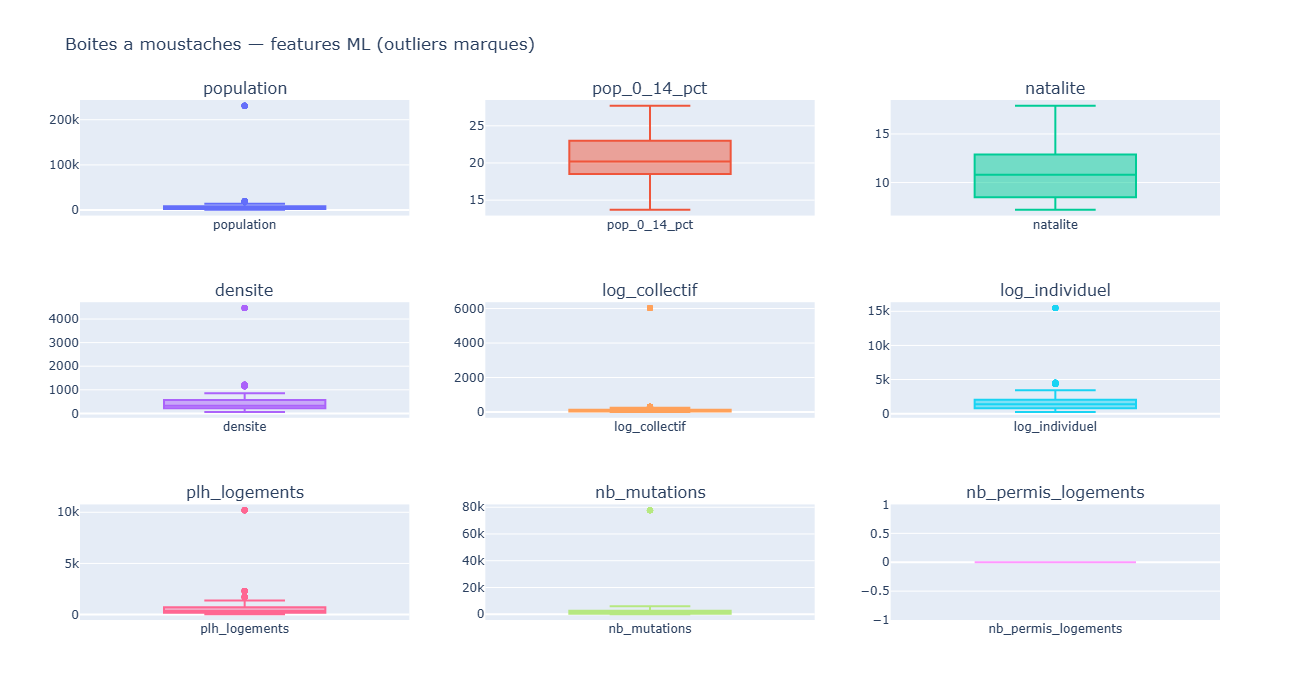

In [7]:
ml_clean = ml[FEATURE_COLUMNS + ALL_TARGETS].dropna()

fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=FEATURE_COLUMNS
)

for i, col in enumerate(FEATURE_COLUMNS):
    r, c = divmod(i, 3)
    fig.add_trace(
        go.Box(y=ml_clean[col], name=col, boxpoints='outliers'),
        row=r+1, col=c+1
    )

fig.update_layout(title='Boites a moustaches — features ML (outliers marques)', showlegend=False, height=700)
fig.show()


In [8]:
print('=== Outliers detectes (methode IQR, seuil 1.5) ===')
for col in FEATURE_COLUMNS:
    s = ml_clean[col]
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        print(f'  {col}: {n_out} outlier(s) — min={s.min():.1f}, max={s.max():.1f}')


=== Outliers detectes (methode IQR, seuil 1.5) ===
  population: 48 outlier(s) — min=677.0, max=230890.0
  densite: 48 outlier(s) — min=59.0, max=4467.0
  log_collectif: 32 outlier(s) — min=1.0, max=6032.0
  log_individuel: 48 outlier(s) — min=244.0, max=15481.0
  plh_logements: 48 outlier(s) — min=36.0, max=10200.0
  nb_mutations: 16 outlier(s) — min=0.0, max=77758.0


## 6. Matrice de correlations features → cibles

La correlation de Pearson mesure la relation **lineaire** entre deux variables (entre -1 et +1).


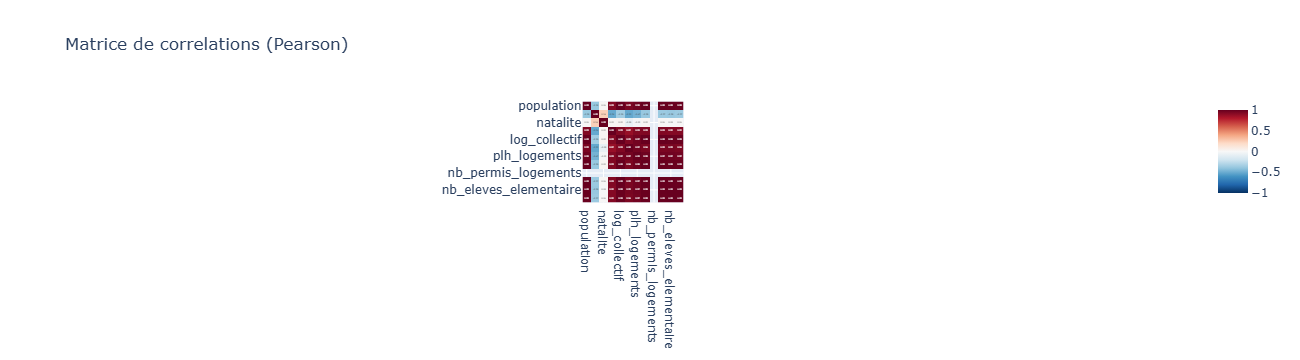

In [9]:
corr_matrix = ml_clean[FEATURE_COLUMNS + ALL_TARGETS].corr()

fig = px.imshow(
    corr_matrix,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Matrice de correlations (Pearson)',
    text_auto='.2f'
)
fig.show()


In [10]:
print('=== Correlations features → cibles ===')
for target in ALL_TARGETS:
    print(f'\n-- {target} --')
    corr_t = corr_matrix[target][FEATURE_COLUMNS].sort_values(ascending=False)
    for feat, val in corr_t.items():
        if pd.isna(val):
            print(f'  {feat:25s} NaN (variance nulle ou donnees insuffisantes)')
            continue
        bar = '#' * int(abs(val) * 20)
        sign = '+' if val >= 0 else '-'
        print(f'  {feat:25s} {sign}{bar} ({val:.3f})')

=== Correlations features → cibles ===

-- nb_eleves_maternelle --
  population                +################### (0.999)
  log_collectif             +################### (0.997)
  nb_mutations              +################### (0.997)
  plh_logements             +################### (0.974)
  log_individuel            +################## (0.947)
  densite                   +################## (0.930)
  natalite                  + (0.009)
  pop_0_14_pct              -####### (-0.371)
  nb_permis_logements       NaN (variance nulle ou donnees insuffisantes)

-- nb_eleves_elementaire --
  population                +################### (0.996)
  nb_mutations              +################### (0.994)
  log_collectif             +################### (0.993)
  plh_logements             +################### (0.974)
  log_individuel            +################### (0.954)
  densite                   +################## (0.923)
  natalite                  - (-0.003)
  pop_0_14_pct            

**Lecture :**
- **r > 0.7** : correlation forte positive → la feature croit avec la cible.
- **r < -0.5** : correlation negative moderee a forte.
- **r proche de 0** : pas de relation lineaire (peut exister une relation non lineaire — voir SHAP dans notebook 02).
- Les features tres correlees entre elles (multicollinearite) peuvent poser probleme pour la regression lineaire/Ridge mais pas pour les arbres.


In [11]:
print('=== Multicollinearite entre features ===')
feat_corr = corr_matrix.loc[FEATURE_COLUMNS, FEATURE_COLUMNS]
pairs = []
for i, f1 in enumerate(FEATURE_COLUMNS):
    for f2 in FEATURE_COLUMNS[i+1:]:
        r = feat_corr.loc[f1, f2]
        if abs(r) > 0.6:
            pairs.append({'feature_1': f1, 'feature_2': f2, 'r': round(r, 3)})

if pairs:
    print('Paires de features fortement correlees (|r| > 0.6) :')
    for p in sorted(pairs, key=lambda x: -abs(x['r'])):
        print(f"  {p['feature_1']:25s} <-> {p['feature_2']:25s}  r={p['r']}")
else:
    print('Pas de multicollinearite forte detectee (|r| <= 0.6 pour toutes les paires).')


=== Multicollinearite entre features ===
Paires de features fortement correlees (|r| > 0.6) :
  population                <-> nb_mutations               r=0.999
  population                <-> log_collectif              r=0.998
  log_collectif             <-> nb_mutations               r=0.998
  population                <-> plh_logements              r=0.978
  plh_logements             <-> nb_mutations               r=0.977
  log_collectif             <-> plh_logements              r=0.967
  log_individuel            <-> plh_logements              r=0.965
  population                <-> log_individuel             r=0.951
  log_individuel            <-> nb_mutations               r=0.944
  densite                   <-> nb_mutations               r=0.932
  log_collectif             <-> log_individuel             r=0.932
  population                <-> densite                    r=0.931
  densite                   <-> log_collectif              r=0.929
  densite                   <-> plh

## 7. Conclusions et recommandations


### Qualite des donnees
- Verifier ci-dessus le taux de nulls : les colonnes > 30% de manquants ne doivent pas etre utilisees comme features sans imputation.
- Les outliers detectes correspondent generalement a Rennes (commune dominante) — a conserver mais surveiller.
- **`date_mutation` est NULL a 100%** dans la source DVF → seul `annee` est utilisable pour la dimension temporelle. ✅ Corrige.

### Variables qualitatives
- `secteur` (public/prive) : non integre comme feature actuellement. Pourrait etre ajoute en ratio `%_prive_par_commune`.
- `type_bien` DVF : utilise en comptage (`nb_mutations`). Un filtrage sur les mutations residentielles uniquement pourrait affiner le signal.
- `periode_construction` : potentiellement utile pour estimer la composition demographique des batiments.

### Temporalite DVF — correctif applique
- **Avant** : `nb_mutations` = comptage all-time par commune (meme valeur pour toutes les rentrees).
- **Apres** : `nb_mutations` = comptage sur les 3 annees precedant chaque rentree (`annee BETWEEN rentree-3 AND rentree-1`).
- Le pipeline ETL (`load_data.py`) et l'inference (`predict.py`) ont ete corrigés en consequence.
- **Action requise** : relancer `docker compose --profile etl run --rm etl` pour regénérer `ml_dataset_commune`.

### Correlations
- Si `population` domine largement les correlations, les autres features apportent de l'information marginale — verifier via SHAP (notebook 02).
- Une forte multicollinearite entre `population` et `densite` est attendue : Ridge regularise cet effet, les arbres l'ignorent naturellement.
- Apres relance de l'ETL, re-executer ce notebook pour verifier si `nb_mutations` a desormais une correlation plus forte avec les cibles.

### Suite recommandee
- Relancer ETL → re-entrainer les modeles (`POST /ml/train`) → re-executer notebooks 02 et 03.